In [1]:
# =============================================================================
# Preprocessing pipeline -- Montpellier urban drainage network (UDN)
# -----------------------------------------------------------------------------
# This notebook parses the RDF/Turtle knowledge base describing the
# Montpellier wastewater and stormwater network, extracts the Pipe and node
# entities into flat pandas tables, applies the physically-impossible-value
# cleaning step described in the manuscript (Section 2.2, Data Pre-Processing),
# and serialises the resulting tables to disk for the downstream attribute-
# reconstruction notebooks (rim elevation, invert elevation, diameter and
# material).
#
# NOTE: this import block is shared across the project's preprocessing and
# reconstruction notebooks. Several imports below (e.g. IsolationForest,
# LinearRegression, cKDTree, rasterio, contextily) are not used in *this
# particular* notebook but are kept for consistency with the shared
# `function.py` module and environment used across the pipeline.
# =============================================================================
import pandas as pd
from rdflib import Namespace
from rdflib.namespace import RDF
from rdflib import Graph
from collections import Counter
from rdflib.namespace import RDF
import matplotlib.pyplot as plt
import numpy as np
import math
from sklearn.metrics import classification_report
from rdflib import Graph
from rdflib import URIRef
import geopandas as gpd
from shapely import wkt
import networkx as nx
from shapely.geometry import Point
from sklearn.metrics import (
    precision_score, recall_score, accuracy_score, f1_score,
    confusion_matrix, balanced_accuracy_score
)
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors
import glob
import rasterio
from rasterio.merge import merge
import contextily as ctx
from rasterio.transform import rowcol
import importlib
import function

importlib.reload(function)

from function import *

In [2]:
# Load the RDF knowledge base (Turtle serialisation) describing the
# Montpellier sewer network ontology (manholes, pipes, and their attributes).
g = Graph()
g.parse("../data/Montpellier/SewerRDF_Montpellier.ttl", format="turtle")

print("Number of triples:", len(g))

Number of triples: 1410958


In [11]:
# ── Ontology namespaces ─────────────────────────────────────────────────────
# Custom namespaces used to query the sewer-network knowledge base. UW is the
# main ontology namespace defining classes (Pipe, Manhole, ...) and predicates
# (hasDiameter, hasRimElevation, ...); UW_wkt is the standard GeoSPARQL
# namespace used for the WKT geometry literals; UW_node is the base IRI under
# which individual node (manhole) instances are declared, and is used below to
# dereference a pipe's endpoint nodes from their local identifiers.
UW = Namespace("http://www.starwars.com/SewerNetworkOntology#")
UW_wkt = Namespace("http://www.opengis.net/ont/geosparql#")
UW_node = Namespace("http://www.starwars.com/SewerNetworkOntology#croquis3/wastewaterregard/")


def short(uri):
    """Return the local name of a URI: its last path segment, or the
    fragment following "#" if present. Used to obtain compact,
    human-readable identifiers from full RDF IRIs."""
    uri = str(uri)
    if "/" in uri:
        uri = uri.split("/")[-1]
    if "#" in uri:
        return uri.split("#")[-1]
    return uri

# ── Pipe table ───────────────────────────────────────────────────────────
# Build one row per Pipe individual in the knowledge base: retrieve its
# endpoint nodes, material, diameter, length and geometry, then fetch the
# rim/invert elevation carried by its two endpoint nodes and derive the
# hydraulic slope and node depth from them (manuscript Section 2.2.3,
# Feature Construction, Eq. 1).

rows_pipe = []
for pipe in g.subjects(RDF.type, UW.Pipe):
    init_node = None
    terminal_node = None
    material = None
    diameter = None
    length = None
    initInvertElevation = None
    terminalInvertElevation = None
    initRimElevation = None
    terminalRimElevation = None
    slope = None
    initDepth = None
    terminalDepth = None
    wkt = None
    u = None
    v = None
      
    # Some pipes list the same node under both hasU and hasV, which is
    # topologically inconsistent (a pipe cannot start and end at the same
    # node); such a shared node is removed from both lists before the
    # endpoints are assigned.
    u_values = list(g.objects(pipe, UW.hasU))
    v_values = list(g.objects(pipe, UW.hasV))
    for i in range(len(u_values)):
        u_values[i] = short(str(u_values[i]))
    for i in range(len(v_values)):
        v_values[i] = short(str(v_values[i]))
    for i in range(len(u_values)):
        if u_values[i] in v_values:
            suppr = u_values[i]
            v_values.remove(suppr)
            u_values.remove(suppr)
            break
    if len(u_values) > 1 or len(v_values) > 1:
        # More than one candidate remains after deduplication: this pipe
        # topology could not be resolved unambiguously and is flagged for
        # manual inspection.
        print("Ambiguous pipe topology: multiple candidate initial/terminal nodes")
        print(u_values)
        print(v_values)
        
    init_node = u_values[0]
    terminal_node = v_values[0]

    material = g.value(pipe, UW.hasMaterial)
    pipe_category = g.value(pipe, UW.hasPipeCategory)
    diameter = g.value(pipe, UW.hasDiameter)
    upstream = g.value(pipe, UW.hasUpstreamElevation)
    downstream = g.value(pipe, UW.hasDownstreamElevation)
    length = g.value(pipe, UW.hasLength)
    wkt = g.value(pipe, UW_wkt.asWKT)

    if init_node and terminal_node:
        # Rim (surface) and invert (bottom) elevations are attributes of the
        # endpoint *nodes*, not of the pipe itself; they are fetched here
        # from the two endpoint nodes identified above.
        initInvertElevation = g.value(UW_node[init_node], UW.hasInvertElevation)
        terminalInvertElevation = g.value(UW_node[terminal_node], UW.hasInvertElevation)
        initRimElevation = g.value(UW_node[init_node], UW.hasRimElevation)
        terminalRimElevation = g.value(UW_node[terminal_node], UW.hasRimElevation)
    
    if length:
        length = length.toPython()
    if initRimElevation:
        initRimElevation = initRimElevation.toPython()
    if terminalRimElevation:
        terminalRimElevation = terminalRimElevation.toPython()
    if initInvertElevation:
        initInvertElevation = initInvertElevation.toPython()
    if terminalInvertElevation:
        terminalInvertElevation = terminalInvertElevation.toPython()
    
        
    if initInvertElevation and terminalInvertElevation and length:
        if not (math.isnan(terminalInvertElevation) or math.isnan(initInvertElevation) or math.isnan(length)):
            slope = ((initInvertElevation - terminalInvertElevation) / length) * 100  # slope in percent

    # Node depth (rim minus invert elevation) at each end of the pipe.
    if initRimElevation and initInvertElevation:
        if not (math.isnan(initRimElevation) or math.isnan(initInvertElevation)):
            initDepth = initRimElevation - initInvertElevation
            
    if terminalRimElevation and terminalInvertElevation:
        if not (math.isnan(terminalRimElevation) or math.isnan(terminalInvertElevation)):
            terminalDepth = terminalRimElevation - terminalInvertElevation
    
    rows_pipe.append({
        "pipe_id": short(str(pipe)),
        "initial_node": init_node if init_node else None,
        "terminal_node": terminal_node if terminal_node else None,
        "material": short(str(material)) if material else None,                 
        "diameter": diameter.toPython() if diameter else None,
        "slope": slope,
        "length": length if length else None,
        "initInvertElevation": initInvertElevation if initInvertElevation else None,
        "terminalInvertElevation": terminalInvertElevation if terminalInvertElevation else None,
        "initRimElevation": initRimElevation if initRimElevation else None,
        "terminalRimElevation": terminalRimElevation if terminalRimElevation else None,
        "initDepth": initDepth if initDepth else None,
        "terminalDepth": terminalDepth if terminalDepth else None,
        "wkt": str(wkt) if wkt else None, 
    })

df_pipe = pd.DataFrame(rows_pipe)


# Cast every attribute that is numeric in nature to a proper numeric dtype
# (RDF literals are otherwise stored as generic Python objects).
numeric_cols = [
    "diameter",
    "slope",
    "length",
    "initInvertElevation",
    "terminalInvertElevation",
    "initRimElevation",
    "terminalRimElevation",
    "initDepth",
    "terminalDepth",
]

for col in numeric_cols:
    df_pipe[col] = pd.to_numeric(df_pipe[col], errors="coerce")

columns_pipe = [
    "initial_node",
    "terminal_node",
    "diameter",
    "initInvertElevation",
    "terminalInvertElevation",
    "initRimElevation",
    "terminalRimElevation",
    "initDepth",
    "terminalDepth",
    "slope",
    "material",
    "wkt",
]

def printNoneValue(columns):
    """Print the count and percentage of missing (NaN) values in `df_pipe`
    for each column name in `columns`."""
    for col in columns:
        n   = df_pipe[col].isna().sum()
        pct = n / len(df_pipe) * 100
        print(f"Missing values in {col:25}: ",df_pipe[col].isna().sum(),f"({pct:1.1f}%)")

printNoneValue(columns_pipe)


df_pipe

Missing values in initial_node             :  0 (0.0%)
Missing values in terminal_node            :  0 (0.0%)
Missing values in diameter                 :  1060 (2.1%)
Missing values in initInvertElevation      :  33093 (65.1%)
Missing values in terminalInvertElevation  :  32292 (63.5%)
Missing values in initRimElevation         :  2131 (4.2%)
Missing values in terminalRimElevation     :  1833 (3.6%)
Missing values in initDepth                :  33191 (65.3%)
Missing values in terminalDepth            :  32402 (63.7%)
Missing values in slope                    :  36104 (71.0%)
Missing values in material                 :  5424 (10.7%)
Missing values in wkt                      :  0 (0.0%)


,pipe_id,initial_node,terminal_node,material,diameter,slope,length,initInvertElevation,terminalInvertElevation,initRimElevation,terminalRimElevation,initDepth,terminalDepth,wkt
0,10205,ass_rega_0028239,ass_rega_0020668,None,NaN,-12.202371,99.734718,107.63,119.80,111.477,121.017,3.847,1.217,MULTILINESTRING ((759680.6635999978 6278403.20...
1,10229,ass_rega_0028263,ass_rega_0021916,None,NaN,NaN,34.712708,NaN,36.38,37.810,37.690,NaN,1.310,MULTILINESTRING ((762178.7484000027 6274918.73...
2,10240,ass_rega_0028274,ass_rega_0021916,None,NaN,NaN,53.802367,NaN,36.38,37.680,37.690,NaN,1.310,MULTILINESTRING ((762128.7682000026 6274848.63...
3,10257,ass_rega_0028291,ass_rega_0027509,None,NaN,NaN,29.811624,NaN,35.64,38.372,37.841,NaN,2.201,MULTILINESTRING ((762033.4610999972 6272276.64...
4,10259,ass_rega_0028293,ass_rega_0028291,None,NaN,NaN,36.249509,NaN,NaN,38.927,38.372,NaN,NaN,MULTILINESTRING ((762003.9315000027 6272297.66...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50832,ass_cana_0052582,ass_appa_0004257,ass_appa_0004256,Grès,NaN,NaN,0.533135,NaN,NaN,NaN,NaN,NaN,NaN,MULTILINESTRING ((762602.9180999994 6272766.74...
50833,ass_cana_0052583,ass_appa_0004253,ass_appa_0004252,Grès,NaN,NaN,5.843068,NaN,NaN,NaN,NaN,NaN,NaN,MULTILINESTRING ((762572.2496000007 6272792.07...
50834,ass_cana_0052584,ass_rega_0027056,ass_appa_0004264,Grès,NaN,NaN,5.235188,28.36,NaN,30.976,NaN,2.616,NaN,MULTILINESTRING ((762660.2854000032 6272728.40...
50835,ass_cana_0052585,ass_appa_0004254,ass_appa_0004255,Grès,NaN,NaN,0.328726,NaN,NaN,NaN,NaN,NaN,NaN,MULTILINESTRING ((762589.8734000027 6272776.60...


In [12]:
# ── Removal of physically impossible values (manuscript Section 2.2.2) ────
# Surface (rim) and bottom (invert) elevations lying outside the admissible
# range for this network are treated as invalid and replaced with NaN, along
# with the physical-consistency checks (invert elevation must not exceed rim
# elevation at the same node) and the removal of non-positive diameters and
# lengths. Any derived variable that depended on a discarded measurement
# (slope, depth) is invalidated accordingly.

columns_pipe = [
    "diameter",
    "length",
    "initInvertElevation",
    "terminalInvertElevation",
    "initRimElevation",
    "terminalRimElevation",
    "initDepth",
    "terminalDepth",
    "slope",
]

nan_before = df_pipe[columns_pipe].isna().sum()

# `discardHeightImpossible(df, column, low, high)` (see function.py) replaces
# values outside [low, high] with NaN. Montpellier's terrain does not reach
# 500 m above sea level, so any elevation outside [0, 500] m is discarded.
df_pipe["initRimElevation"] = discardHeightImpossible(df_pipe, "initRimElevation", 0, 500)
df_pipe["terminalRimElevation"] = discardHeightImpossible(df_pipe, "terminalRimElevation", 0, 500) 
df_pipe["initInvertElevation"] = discardHeightImpossible(df_pipe, "initInvertElevation", 0, 500)
df_pipe["terminalInvertElevation"] = discardHeightImpossible(df_pipe, "terminalInvertElevation", 0, 500)
# Hydraulically impossible configuration: invert elevation above rim
# elevation at the same node. Both values are discarded rather than
# arbitrarily corrected, so they become targets for the reconstruction step.
mask = df_pipe["initInvertElevation"] > df_pipe["initRimElevation"]
df_pipe.loc[mask, "initInvertElevation"] = np.nan
df_pipe.loc[mask, "initRimElevation"] = np.nan
df_pipe.loc[mask, "initDepth"] = np.nan

mask = df_pipe["terminalInvertElevation"] > df_pipe["terminalRimElevation"]
df_pipe.loc[mask, "terminalInvertElevation"] = np.nan
df_pipe.loc[mask, "terminalRimElevation"] = np.nan
df_pipe.loc[mask, "terminalDepth"] = np.nan

# Slope depends on both invert elevations: if either is missing, the
# derived slope is no longer computable and is invalidated.
mask = (df_pipe["initInvertElevation"].isna()) | (df_pipe["terminalInvertElevation"].isna())
df_pipe.loc[mask, "slope"] = np.nan

# Non-positive diameters and lengths are physically invalid.
mask = (df_pipe["diameter"] <= 0.0) | (df_pipe["diameter"] >= 5000)
df_pipe.loc[mask, "diameter"] = np.nan

mask = df_pipe["length"] <= 0.0
df_pipe.loc[mask, "length"] = np.nan

nan_after = df_pipe[columns_pipe].isna().sum()

nan_diff = pd.DataFrame({
    "NaN_before": nan_before,
    "NaN_after": nan_after,
    "increase": nan_after - nan_before,
    "increase_%": ((nan_after - nan_before) / len(df_pipe) * 100).round(2)
})

print(nan_diff)

                         NaN_before  NaN_after  increase  increase_%
diameter                       1060       1060         0        0.00
length                            0          0         0        0.00
initInvertElevation           33093      33368       275        0.54
terminalInvertElevation       32292      32606       314        0.62
initRimElevation               2131       2613       482        0.95
terminalRimElevation           1833       2366       533        1.05
initDepth                     33191      33376       185        0.36
terminalDepth                 32402      32602       200        0.39
slope                         36104      36381       277        0.54


material
PVC%20inconnu       23977
Amiante-ciment      12955
Béton                2738
Fonte%20inconnue     1593
PRV%20A               838
Indéterminé           828
Fonte%20ductile       750
PP%20lisse            626
Grès                  401
Maçonné               392
Pierre                 89
Béton%20armé           87
PEHD%20lisse           37
PVC%20U%20lisse        37
PEHD%20inconnu         28
Acier                  11
Polypropylène          10
Polyéthylène            6
PVC%20U%20annelé        4
Inox                    3
Fonte%20grise           3
Name: count, dtype: int64


<Figure size 640x480 with 0 Axes>

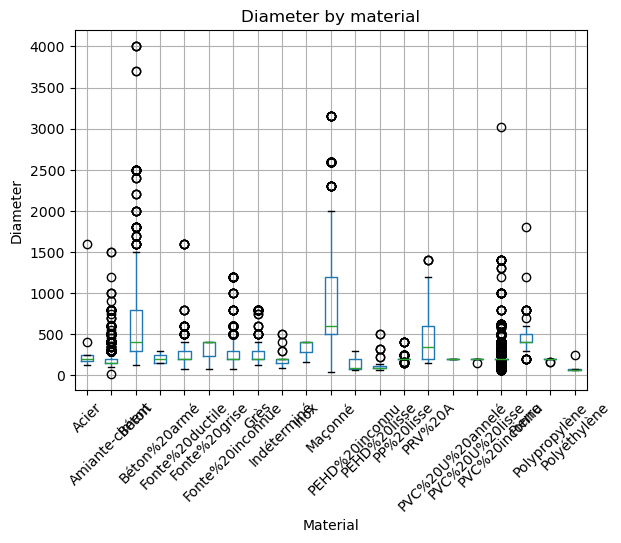

material
Plastic            24725
Asbestos-cement    12955
Undetermined        6252
Concrete            3707
Metal               2360
Glass                838
Name: count, dtype: int64


<Figure size 640x480 with 0 Axes>

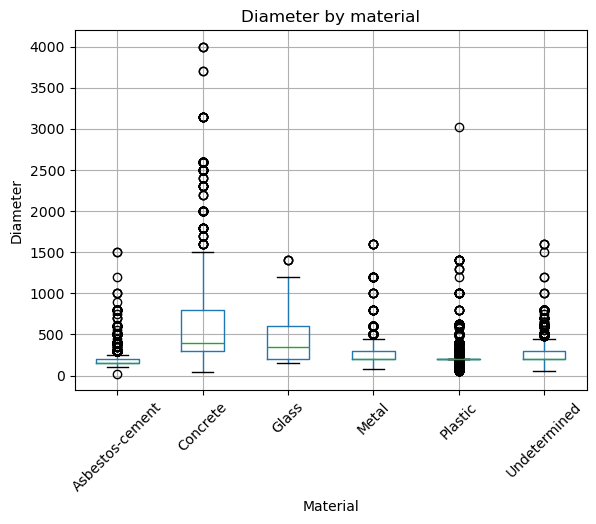

In [13]:
# ── Material category grouping (manuscript Section 2.2.4) ─────────────────
# The raw "material" field lists about twenty fine-grained, unevenly
# represented labels. They are grouped here into six broader classes with
# enough occurrences each to be usable by the diameter/material compatibility
# scoring (Section 2.5): Plastic, Concrete, Metal, Asbestos-cement, Glass, and
# Undetermined (which also collects every missing material value).

def map_material(mat):
    if mat in plastic:
        return "Plastic"
    elif mat in concrete:
        return "Concrete"
    elif mat in metal:
        return "Metal"
    elif mat in asbestos_cement:
        return "Asbestos-cement"
    elif mat in glass:
        return "Glass"
    else:
        return "Undetermined"

print(df_pipe["material"].value_counts())

boxplot_mat_dia(df_pipe)

plastic = ["PVC%20inconnu", "PVC%20U%20lisse", "PVC%20U%20annelé", "PP%20lisse", "Polypropylène", "PEHD%20lisse", "PEHD%20inconnu", "Polyéthylène"]
concrete = ["Béton", "Maçonné", "Grès", "Pierre", "Béton%20armé"]
metal = ["Fonte%20inconnue", "Fonte%20ductile", "Fonte%20grise", "Acier", "Inox"]
asbestos_cement = ["Amiante-ciment"]
glass = ["PRV%20A"]

df_pipe["material"] = df_pipe["material"].apply(map_material)

print(df_pipe["material"].value_counts())

boxplot_mat_dia(df_pipe)

In [14]:
# ── Node table ───────────────────────────────────────────────────────────
# Build one row per node individual in the knowledge base (Manhole,
# Appurtenance, ConnectionPoint, Structure, PumpingStation, AirValve,
# StormOverflow, Valve, DischargeStructure, TreatmentPlant, Flowmeter,
# Stormwater and Wastewater types): coordinates, geometry, rim/invert
# elevation, derived depth, material, and connectivity (upstream/downstream
# pipes and node degree).
NODE_TYPES = [
    UW.Manhole,
    UW.Appurtenance,
    UW.ConnectionPoint,
    UW.Structure,
    UW.PumpingStation,
    UW.AirValve,
    UW.StormOverflow,
    UW.Valve,
    UW.DischargeStructure,
    UW.TreatmentPlant,
    UW.Flowmeter,
    UW.Stormwater,
    UW.Wastewater
]

rows_node = []

for node_type in NODE_TYPES:
    for node in g.subjects(RDF.type, node_type):

        node_id   = short(str(node))
        type_name = short(str(node_type))

        # ── Coordinates and geometry ──────────────────────────────────────
        x   = g.value(node, UW.hasXCoordinate)
        y   = g.value(node, UW.hasYCoordinate)
        wkt = g.value(node, UW_wkt.asWKT)

        # ── Elevations ──────────────────────────────────────────────────
        rimElevation    = g.value(node, UW.hasRimElevation)
        invertElevation = g.value(node, UW.hasInvertElevation)

        geocode = g.value(node, UW.hasGeocode)

        # Node depth = rim elevation minus invert elevation, when both are
        # available and valid.
        depth = None
        if rimElevation and invertElevation:
            r_val = rimElevation.toPython()
            i_val = invertElevation.toPython()
            if not (math.isnan(r_val) or math.isnan(i_val)):
                depth = r_val - i_val

        # ── Material ────────────────────────────────────────────────────
        material = g.value(node, UW.hasMaterial)

        # Connectivity: pipes for which this node is respectively the
        # terminal or initial node, used below to derive the node degree.
        pipes_end   = [short(str(p)) for p in g.subjects(UW.hasTerminalNode, node)]
        pipes_start = [short(str(p)) for p in g.subjects(UW.hasInitialNode,  node)]

        rows_node.append({
            "node_id"           : node_id,
            "node_type"         : type_name,
            "x"                 : x.toPython()               if x                else None,
            "y"                 : y.toPython()               if y                else None,
            "wkt"               : str(wkt)                   if wkt              else None,
            "rimElevation"      : rimElevation.toPython()    if rimElevation     else None,
            "invertElevation"   : invertElevation.toPython() if invertElevation  else None,
            "depth"             : depth,
            "material"          : short(str(material))       if material         else None,
            "pipes_end"    : pipes_end,
            "pipes_start"  : pipes_start,
            "degree"            : len(pipes_end) + len(pipes_start),
            "geocode"           : short(str(geocode))                   if geocode           else None,
        })

df_node = pd.DataFrame(rows_node)

# ── Numeric conversion ───────────────────────────────────────────────────
for col in ["x", "y", "rimElevation", "invertElevation", "depth", "degree"]:
    df_node[col] = pd.to_numeric(df_node[col], errors="coerce")


df_node = df_node.dropna(subset=["x"]) #ass_pref_0000047 is the only node without x and y coordinate


# ── Summary ───────────────────────────────────────────────────────────────
print(f"Total nodes: {len(df_node)}")
print()
print("Distribution by node type:")
print(df_node["node_type"].value_counts().to_string())
print()
print("Missing values per column:")
for col in ["x", "y", "rimElevation", "invertElevation", "depth", "material","wkt", "geocode"]:
    n   = df_node[col].isna().sum()
    pct = n / len(df_node) * 100
    print(f"  {col:<22} {n:>5} ({pct:4.1f}%)")

df_node

Total nodes: 50622

Distribution by node type:
node_type
Manhole               49665
Appurtenance            471
PumpingStation          280
StormOverflow            68
Valve                    33
Structure                30
AirValve                 26
ConnectionPoint          21
DischargeStructure       15
TreatmentPlant           13

Missing values per column:
  x                          0 ( 0.0%)
  y                          0 ( 0.0%)
  rimElevation            2060 ( 4.1%)
  invertElevation        32914 (65.0%)
  depth                  32970 (65.1%)
  material               33090 (65.4%)
  wkt                        0 ( 0.0%)
  geocode                  371 ( 0.7%)


,node_id,node_type,x,y,wkt,rimElevation,invertElevation,depth,material,pipes_end,pipes_start,degree,geocode
77,ass_rega_0028243,Manhole,781350.0354,6.283230e+06,POINT (781350.0354000032 6283230.0513),18.025,NaN,NaN,None,[],[],0,340022
78,ass_rega_0067344,Manhole,769943.2994,6.270719e+06,POINT (769943.2994000018 6270719.2771999985),3.752,2.40,1.352,Indéterminé,[],[],0,340337
79,ass_rega_0067351,Manhole,768785.3952,6.270583e+06,POINT (768785.3951999992 6270583.0830999985),10.846,NaN,NaN,Indéterminé,[],[],0,340337
80,ass_rega_0067353,Manhole,769019.5744,6.270087e+06,POINT (769019.5744000003 6270087.196199998),21.170,19.83,1.340,Indéterminé,[],[],0,340337
81,ass_rega_0067365,Manhole,769788.9006,6.269998e+06,POINT (769788.9006000012 6269997.883400001),5.520,3.88,1.640,Indéterminé,[],[],0,340337
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50694,ass_step_0000010,TreatmentPlant,761091.4044,6.278758e+06,POINT (761091.4043999738 6278758.177302571),NaN,NaN,NaN,None,[ass_cana_0004760],[],1,340179
50695,ass_step_0000013,TreatmentPlant,770264.4958,6.271686e+06,POINT (770264.495799975 6271685.799302588),NaN,NaN,NaN,None,[ass_cana_0009626],[],1,340337
50696,ass_step_0000014,TreatmentPlant,782678.6413,6.284082e+06,POINT (782678.641299967 6284082.03940256),NaN,NaN,NaN,None,[ass_cana_0006204],[],1,340022
50697,ass_step_0000015,TreatmentPlant,758318.5502,6.269522e+06,POINT (758318.5501999767 6269522.139302595),NaN,NaN,NaN,None,[ass_cana_0010453],[],1,340087


In [15]:
# ── Removal of physically impossible node-level values ─────────────────────
# Same cleaning rule as for the pipe table (Section 2.2.2): elevations
# outside the admissible range are discarded, and invert elevations exceeding
# the rim elevation at the same node are set to NaN as a hydraulically
# impossible configuration.
columns = [
    "invertElevation",
    "rimElevation",
]

nan_before = df_node[columns].isna().sum()

df_node["invertElevation"] = discardHeightImpossible(df_node, "invertElevation", 0, 500)
df_node["rimElevation"] = discardHeightImpossible(df_node, "rimElevation", 0, 500)

mask = df_node["invertElevation"] > df_node["rimElevation"]
df_node.loc[mask, "invertElevation"] = np.nan
df_node.loc[mask, "rimElevation"] = np.nan

nan_after = df_node[columns].isna().sum()

nan_diff = pd.DataFrame({
    "NaN_before": nan_before,
    "NaN_after": nan_after,
    "increase": nan_after - nan_before,
    "increase_%": ((nan_after - nan_before) / len(df_node) * 100).round(2)
})

print(nan_diff)

                 NaN_before  NaN_after  increase  increase_%
invertElevation       32914      33188       274        0.54
rimElevation           2060       2542       482        0.95


In [16]:
# ── Serialisation ───────────────────────────────────────────────────────
# Save the cleaned pipe and node tables to disk (pickle format) so that the
# downstream reconstruction notebooks (rim elevation, invert elevation,
# diameter and material) can load them directly without re-parsing the RDF
# knowledge base.
df_pipe.to_pickle("../data/Montpellier/df_pipe_Montpellier.pkl")
df_node.to_pickle("../data/Montpellier/df_node_Montpellier.pkl")